In [1]:
import os
import pandas as pd

In [2]:
companies = ["AAPL", "GOOGL", "AMZN", "TSLA"]

In [3]:
datasets = {}
for company in companies:
    file_path = f"datasets/{company}.csv"
    datasets[company] = pd.read_csv(file_path)

    print(f"\n{company} Dataset")
    print(datasets[company].head())


AAPL Dataset
       Date       Close        High         Low        Open    Volume
0  8/2/2021  141.845917  143.239805  141.582729  142.664705  62880000
1  8/3/2021  143.639465  144.302290  141.514498  142.128597  64786600
2  8/4/2021  143.239792  144.058580  142.586710  143.551720  56368300
3  8/5/2021  143.347000  144.107305  142.479472  143.269018  46397700
4  8/6/2021  142.663650  143.610578  142.165788  142.868662  54126800

GOOGL Dataset
       Date       Close        High         Low        Open    Volume
0  8/2/2021  133.669235  134.146994  132.618055  133.929425  21634000
1  8/3/2021  134.437912  134.539005  132.147719  133.947252  20762000
2  8/4/2021  133.937851  134.457247  133.304959  134.159881  19676000
3  8/5/2021  135.053955  135.151600  133.660806  134.487975  17870000
4  8/6/2021  134.545441  135.272998  134.021598  134.846286  20488000

AMZN Dataset
       Date       Close        High         Low        Open    Volume
0  8/2/2021  166.574005  167.945999  165.850006

In [4]:
aapl = pd.read_csv("datasets/AAPL.csv")
googl = pd.read_csv("datasets/GOOGL.csv")
amzn = pd.read_csv("datasets/AMZN.csv")
tsla = pd.read_csv("datasets/TSLA.csv")

print(aapl.head())
print(googl.head())

       Date       Close        High         Low        Open    Volume
0  8/2/2021  141.845917  143.239805  141.582729  142.664705  62880000
1  8/3/2021  143.639465  144.302290  141.514498  142.128597  64786600
2  8/4/2021  143.239792  144.058580  142.586710  143.551720  56368300
3  8/5/2021  143.347000  144.107305  142.479472  143.269018  46397700
4  8/6/2021  142.663650  143.610578  142.165788  142.868662  54126800
       Date       Close        High         Low        Open    Volume
0  8/2/2021  133.669235  134.146994  132.618055  133.929425  21634000
1  8/3/2021  134.437912  134.539005  132.147719  133.947252  20762000
2  8/4/2021  133.937851  134.457247  133.304959  134.159881  19676000
3  8/5/2021  135.053955  135.151600  133.660806  134.487975  17870000
4  8/6/2021  134.545441  135.272998  134.021598  134.846286  20488000


In [5]:
for company, data in datasets.items():
    print(company)
    print(data.shape)

AAPL
(1254, 6)
GOOGL
(1254, 6)
AMZN
(1254, 6)
TSLA
(1254, 6)


In [6]:
 print(data.columns)

Index(['Date', 'Close', 'High', 'Low', 'Open', 'Volume'], dtype='str')


In [7]:
print(data.info())

<class 'pandas.DataFrame'>
RangeIndex: 1254 entries, 0 to 1253
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    1254 non-null   str    
 1   Close   1254 non-null   float64
 2   High    1254 non-null   float64
 3   Low     1254 non-null   float64
 4   Open    1254 non-null   float64
 5   Volume  1254 non-null   int64  
dtypes: float64(4), int64(1), str(1)
memory usage: 58.9 KB
None


In [8]:
print(data.isnull().sum())

Date      0
Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64


In [9]:
X = data[["Open", "High", "Low", "Volume"]]
y = data["Close"]

In [10]:
print(X.head())
print(y.head())

         Open        High         Low     Volume
0  233.333328  242.313339  232.800003  100847400
1  239.666672  240.883331  233.669998   64860900
2  237.000000  241.633331  236.309998   51007800
3  238.666672  240.316666  237.136673   38758800
4  237.300003  238.776672  232.543335   46869000
0    236.556671
1    236.580002
2    236.973328
3    238.210007
4    233.033341
Name: Close, dtype: float64


In [11]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [13]:
print("Training Data :", X_train.shape)
print("Testing Data  :", X_test.shape)

Training Data : (1003, 4)
Testing Data  : (251, 4)


In [14]:
model = LinearRegression()

In [15]:
model.fit(X_train, y_train)
print(f"AAPL model trained successfully!")

AAPL model trained successfully!


In [16]:
y_pred = model.predict(X_test)

In [17]:
print("\nActual Price")
print(y_test.head())

print("\nPredicted Price")
print(y_pred[:5])


Actual Price
1253    308.850006
101     355.666656
51      270.359985
63      371.333344
1069    468.369995
Name: Close, dtype: float64

Predicted Price
[304.60188734 341.94363462 269.84489482 363.23311911 461.02478766]


In [18]:
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print(f"\nR² Score : {r2:.4f}")
print(f"MSE : {mse:.4f}")
print(f"RMSE : {rmse:.4f}")


R² Score : 0.9953
MSE : 32.2794
RMSE : 5.6815


In [19]:
with open(f"models/AAPL_accuracy.txt", "w") as file:
    file.write(f"{r2*100:.2f}")

In [20]:
with open(f"models/AMNZ_accuracy.txt", "w") as file:
    file.write(f"{r2*100:.2f}")

In [21]:
with open(f"models/GOOGL_accuracy.txt", "w") as file:
    file.write(f"{r2*100:.2f}")

In [22]:
with open(f"models/TSLA_accuracy.txt", "w") as file:
    file.write(f"{r2*100:.2f}")

In [23]:
import joblib

In [24]:
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](4,)","[0.33,0.34,0.32,0. ]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](4,)","['Open','High','Low','Volume']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-0.1704
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,4
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(2)


In [25]:
joblib.dump(model, f"models/AAPL_model.pkl")
print(f"AAPL model saved successfully!")

AAPL model saved successfully!


In [26]:
joblib.dump(model, f"models/AMZN_model.pkl")
print(f"AMZN model saved successfully!")

AMZN model saved successfully!


In [27]:
joblib.dump(model, f"models/GOOGL_model.pkl")
print(f"GOOGL model saved successfully!")

GOOGL model saved successfully!


In [28]:
joblib.dump(model, f"models/TSLA_model.pkl")
print(f"TSLA model saved successfully!")

TSLA model saved successfully!


In [29]:
y_pred = model.predict(X_test)

In [30]:
prediction_df = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})
print(prediction_df.head())

       Actual   Predicted
0  308.850006  304.601887
1  355.666656  341.943635
2  270.359985  269.844895
3  371.333344  363.233119
4  468.369995  461.024788


In [31]:
prediction_df.to_csv(
    f"predictions/AAPL_predictions.csv",
    index=False
)
print(f"AAPL predictions saved successfully!")

AAPL predictions saved successfully!


In [32]:
prediction_df.to_csv(
    f"predictions/AMZN_predictions.csv",
    index=False
)
print(f"AMZN predictions saved successfully!")

AMZN predictions saved successfully!


In [33]:
prediction_df.to_csv(
    f"predictions/GOOGL_predictions.csv",
    index=False
)
print(f"GOOGL predictions saved successfully!")

GOOGL predictions saved successfully!


In [34]:
prediction_df.to_csv(
    f"predictions/TSLA_predictions.csv",
    index=False
)
print(f"TSLA predictions saved successfully!")

TSLA predictions saved successfully!


In [35]:
print("\n--------------------------------")
print(f"AAPL Completed Successfully")
print(f"R² Score : {r2:.4f}")
print(f"MSE      : {mse:.4f}")
print(f"RMSE     : {rmse:.4f}")
print("--------------------------------\n")


--------------------------------
AAPL Completed Successfully
R² Score : 0.9953
MSE      : 32.2794
RMSE     : 5.6815
--------------------------------



In [36]:
import matplotlib.pyplot as plt

In [37]:
prediction_df.to_csv(
    f"predictions/GOOGL_predictions.csv",
    index=False
)

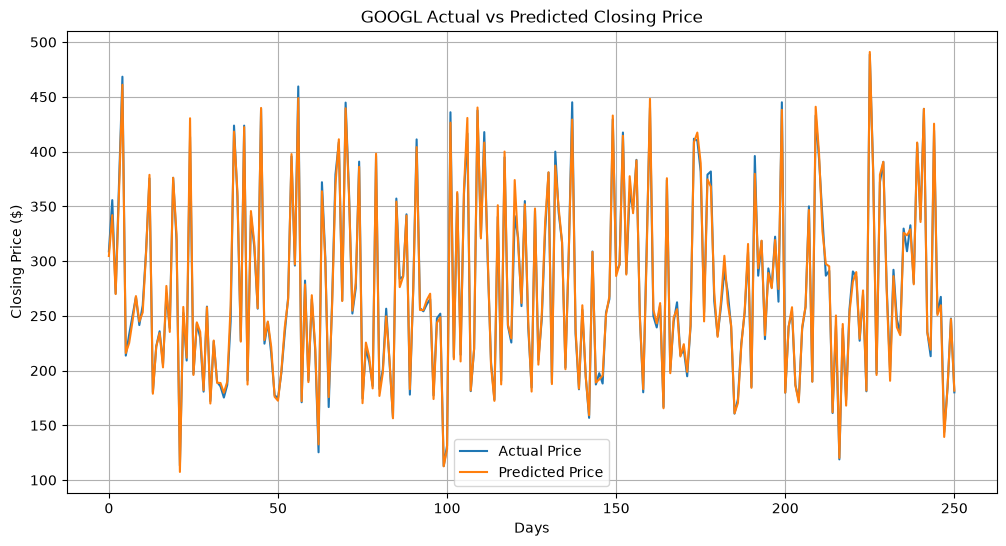

In [38]:
plt.figure(figsize=(12,6))
plt.plot(
    prediction_df["Actual"].values,
    label="Actual Price"
)
plt.plot(
    prediction_df["Predicted"].values,
    label="Predicted Price"
)
plt.title(f"GOOGL Actual vs Predicted Closing Price")
plt.xlabel("Days")
plt.ylabel("Closing Price ($)")
plt.legend()
plt.grid(True)